# 04 — Evaluation
**CLPapersAIAgent | Member 4**

This notebook evaluates and compares three retrieval methods built in notebook 02:
- **BM25** — lexical keyword search
- **Dense** — semantic vector search (Qdrant)
- **Hybrid** — weighted combination of BM25 + Dense

Metrics computed: Recall@k, NDCG@k, MRR, Avg Latency, p95 Latency

In [53]:
import sys, os
sys.path.append(os.path.abspath(".."))

import json
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from IPython.display import display, Image
from pymongo import MongoClient
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

# ── Notebook cache paths ──
CACHE_01 = Path("../notebook_cache/01_ingestion")
CACHE_02 = Path("../notebook_cache/02_semantic_retrieval")
CACHE_03 = Path("../notebook_cache/03_graph_build")
CACHE_04 = Path("../notebook_cache/04_evaluation")
CACHE_04.mkdir(parents=True, exist_ok=True)

# ── Constants ──
TOP_K          = 5
COLLECTION_NAME = "clpapers_chunks"  # same name as Member 2
VECTOR_DIM     = 384

# ── Qdrant in-memory (no Docker, no server needed) ──
qdrant = QdrantClient(":memory:")
qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=VECTOR_DIM, distance=Distance.COSINE)
)

# ── Plot styling (consistent with all other notebooks) ──
matplotlib.rcParams['figure.facecolor'] = '#0f1117'
matplotlib.rcParams['axes.facecolor']   = '#161b22'
matplotlib.rcParams['text.color']       = '#e6edf3'
matplotlib.rcParams['axes.labelcolor']  = '#8b949e'
matplotlib.rcParams['xtick.color']      = '#8b949e'
matplotlib.rcParams['ytick.color']      = '#8b949e'

print("Imports loaded successfully")
print("Qdrant running in memory — no Docker needed")
print(f"Cache 01 exists: {CACHE_01.exists()}")
print(f"Cache 02 exists: {CACHE_02.exists()}")
print(f"Cache 03 exists: {CACHE_03.exists()}")

Imports loaded successfully
Qdrant running in memory — no Docker needed
Cache 01 exists: True
Cache 02 exists: True
Cache 03 exists: True


In [54]:
from pathlib import Path
import shutil
import json

# Detect project root
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd

CACHE_01 = PROJECT_ROOT / "notebook_cache" / "01_ingestion"
CACHE_01.mkdir(parents=True, exist_ok=True)

target_file = CACHE_01 / "labeled_query_set.json"

# Search possible locations
candidates = []

# outputs/test folders
outputs_dir = PROJECT_ROOT / "outputs"
if outputs_dir.exists():
    candidates.extend(sorted(outputs_dir.glob("test*/labeled_query_set.json"), reverse=True))
    candidates.extend(sorted(outputs_dir.glob("test*/query_set.json"), reverse=True))

# notebook cache possible names
candidates.extend([
    CACHE_01 / "query_set.json",
    CACHE_01 / "queries.json",
])

# remove missing candidates
candidates = [p for p in candidates if p.exists()]

print("Project root:", PROJECT_ROOT)
print("Target:", target_file)

if target_file.exists():
    print("✅ labeled_query_set.json already exists:", target_file)

elif candidates:
    source_file = candidates[0]
    shutil.copy2(source_file, target_file)
    print("✅ Copied:")
    print("FROM:", source_file)
    print("TO:  ", target_file)

else:
    print("❌ Could not find labeled_query_set.json or query_set.json.")
    print("Run 01_ingestion_pipeline.ipynb again, especially the query set / labeled query cell.")

Project root: C:\Users\97150\Documents\GitHub\CLPapersAIAgent
Target: C:\Users\97150\Documents\GitHub\CLPapersAIAgent\notebook_cache\01_ingestion\labeled_query_set.json
✅ labeled_query_set.json already exists: C:\Users\97150\Documents\GitHub\CLPapersAIAgent\notebook_cache\01_ingestion\labeled_query_set.json


In [55]:
# ── Load embedding model ──
print("Loading embedding model...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded")

# ── Generate embeddings and upload to in-memory Qdrant ──
print(f"Generating embeddings for {len(chunks)} chunks...")
print("This will take ~7 minutes...")

texts = [c["text"] for c in chunks]
t0 = time.time()

embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

elapsed = round(time.time() - t0, 2)
print(f"Embeddings generated in {elapsed}s")

# ── Upload to Qdrant ──
BATCH_SIZE = 100
total_uploaded = 0

for i in range(0, len(chunks), BATCH_SIZE):
    batch_chunks     = chunks[i:i+BATCH_SIZE]
    batch_embeddings = embeddings[i:i+BATCH_SIZE]

    points = [
        PointStruct(
            id=i+j,
            vector=batch_embeddings[j].tolist(),
            payload={
                "chunk_id":   batch_chunks[j]["chunk_id"],
                "paper_id":   batch_chunks[j]["paper_id"],
                "title":      batch_chunks[j].get("title", "unknown"),
                "text":       batch_chunks[j]["text"][:500],
            }
        )
        for j in range(len(batch_chunks))
    ]

    qdrant.upsert(collection_name=COLLECTION_NAME, points=points)
    total_uploaded += len(points)

print(f"✅ Uploaded {total_uploaded} vectors to Qdrant")
print("Dense and Hybrid search now ready")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded
Generating embeddings for 6728 chunks...
This will take ~7 minutes...


Batches:   0%|          | 0/211 [00:00<?, ?it/s]

Embeddings generated in 307.19s
✅ Uploaded 6728 vectors to Qdrant
Dense and Hybrid search now ready


SYSTEM DATAFLOW — Evaluation covers the Retrieval layer

This evaluation (Member 4) benchmarks the three retrieval 
methods produced in Stage 02:
  → BM25       (lexical)
  → Dense      (semantic via Qdrant)  
  → Hybrid     (BM25 + Dense combined)

Metrics: Recall@k, NDCG@k, MRR, Latency



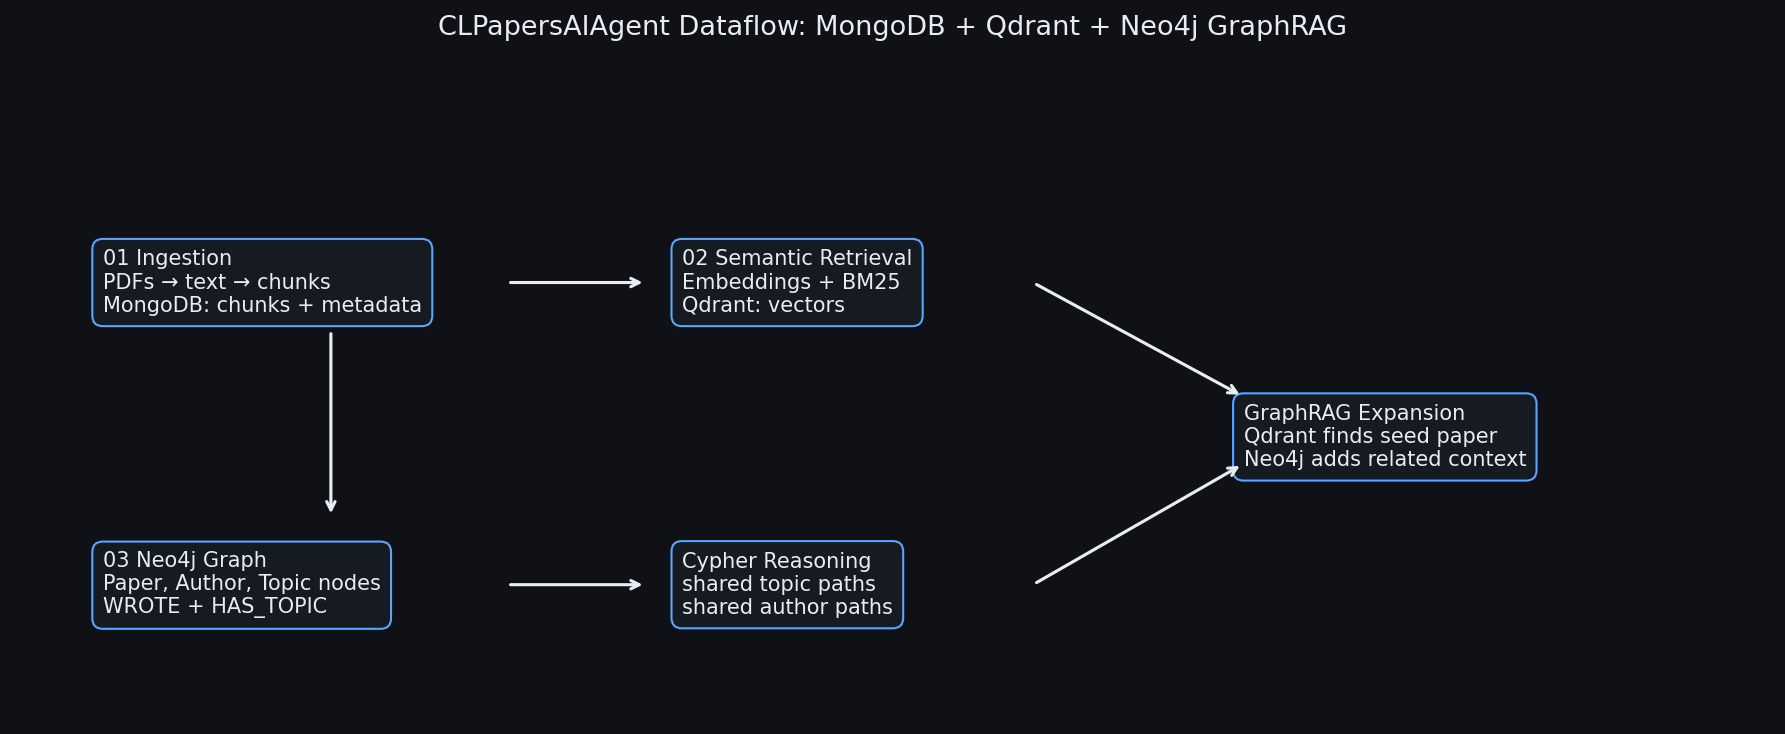

In [56]:
from IPython.display import Image, display

print("=" * 60)
print("SYSTEM DATAFLOW — Evaluation covers the Retrieval layer")
print("=" * 60)
print("""
This evaluation (Member 4) benchmarks the three retrieval 
methods produced in Stage 02:
  → BM25       (lexical)
  → Dense      (semantic via Qdrant)  
  → Hybrid     (BM25 + Dense combined)

Metrics: Recall@k, NDCG@k, MRR, Latency
""")

display(Image(str(CACHE_03 / "neo4j_dataflow_diagram.png")))

In [57]:
def dcg(rels):
    return sum(r / math.log2(i + 2) for i, r in enumerate(rels))

def ndcg_at_k(retrieved, relevant, k):
    if not relevant: return 0.0
    rels  = [1 if pid in relevant else 0 for pid in retrieved[:k]]
    ideal = [1] * min(len(relevant), k)
    idcg  = dcg(ideal)
    return dcg(rels) / idcg if idcg > 0 else 0.0

def recall_at_k(retrieved, relevant, k):
    if not relevant: return 0.0
    hits = sum(1 for pid in retrieved[:k] if pid in relevant)
    return hits / len(relevant)

def mrr(retrieved, relevant):
    for i, pid in enumerate(retrieved, 1):
        if pid in relevant:
            return 1.0 / i
    return 0.0

print("Metric functions ready")

Metric functions ready


In [58]:
K_VALUES = list(range(1, 11))  # k = 1 to 10
methods  = {"BM25": bm25_search, "Dense": dense_search, "Hybrid": hybrid_search}

results_store = {}  # method -> list of per-query dicts

for method_name, search_fn in methods.items():
    per_query = []
    for q in labeled_queries:
        relevant = set(q["relevant_paper_ids"])
        hits, latency = search_fn(q["text"], top_k=10)
        retrieved_pids = [h["paper_id"] for h in hits]
        row = {"query_id": q["query_id"], "latency_ms": latency}
        for k in K_VALUES:
            row[f"recall@{k}"]  = recall_at_k(retrieved_pids, relevant, k)
            row[f"ndcg@{k}"]    = ndcg_at_k(retrieved_pids, relevant, k)
        row["mrr"] = mrr(retrieved_pids, relevant)
        per_query.append(row)
    results_store[method_name] = per_query

print("Evaluation complete")

Evaluation complete


SECTION 1 — SEMANTIC RETRIEVAL OUTPUTS (Member 2)


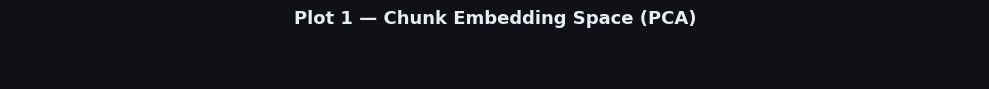

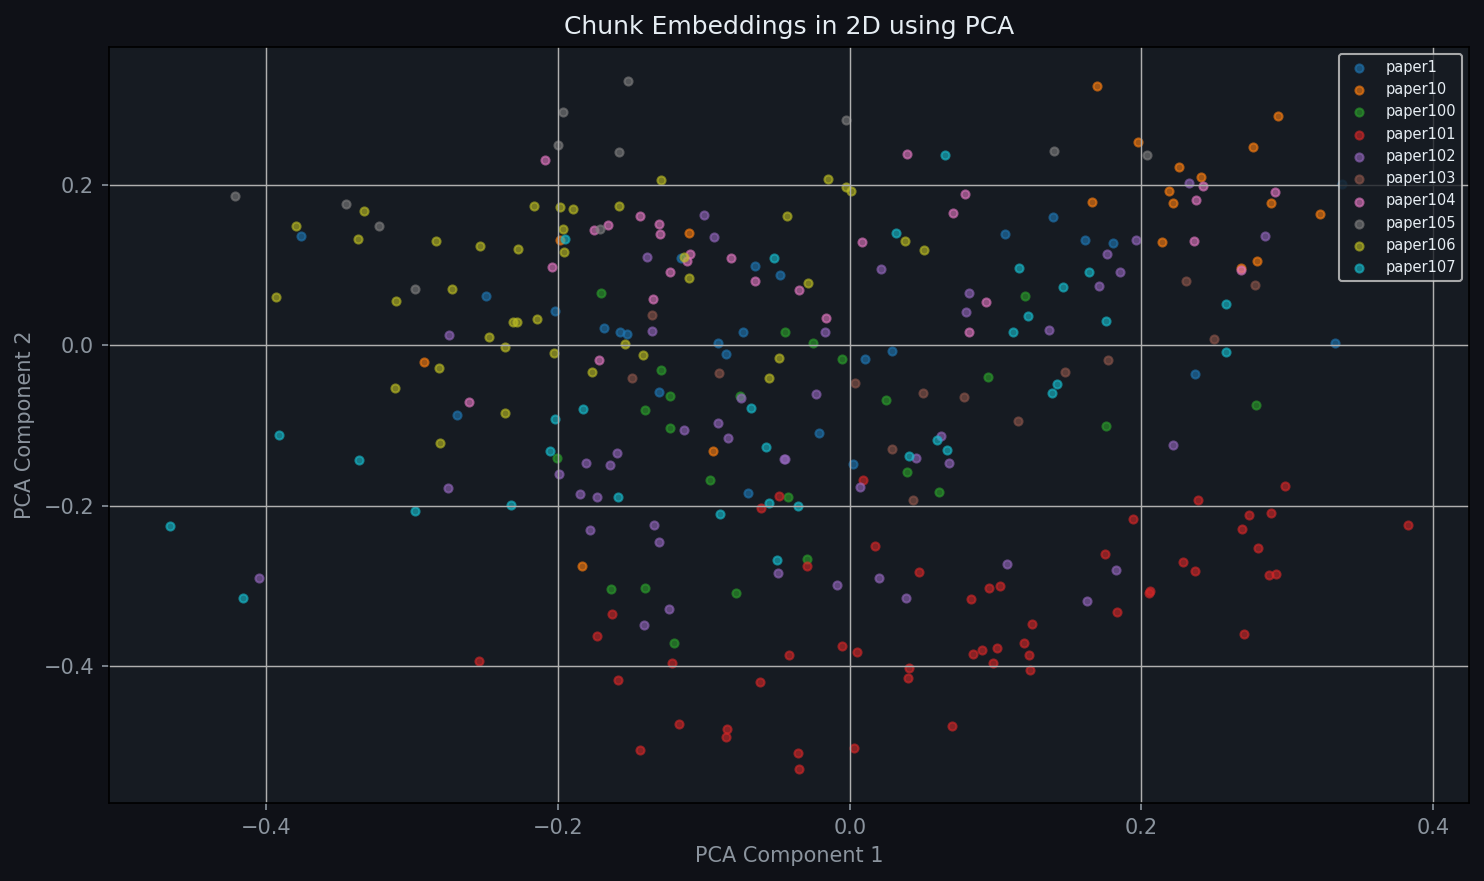

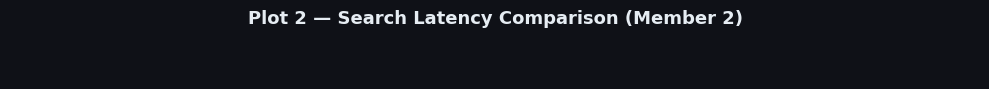

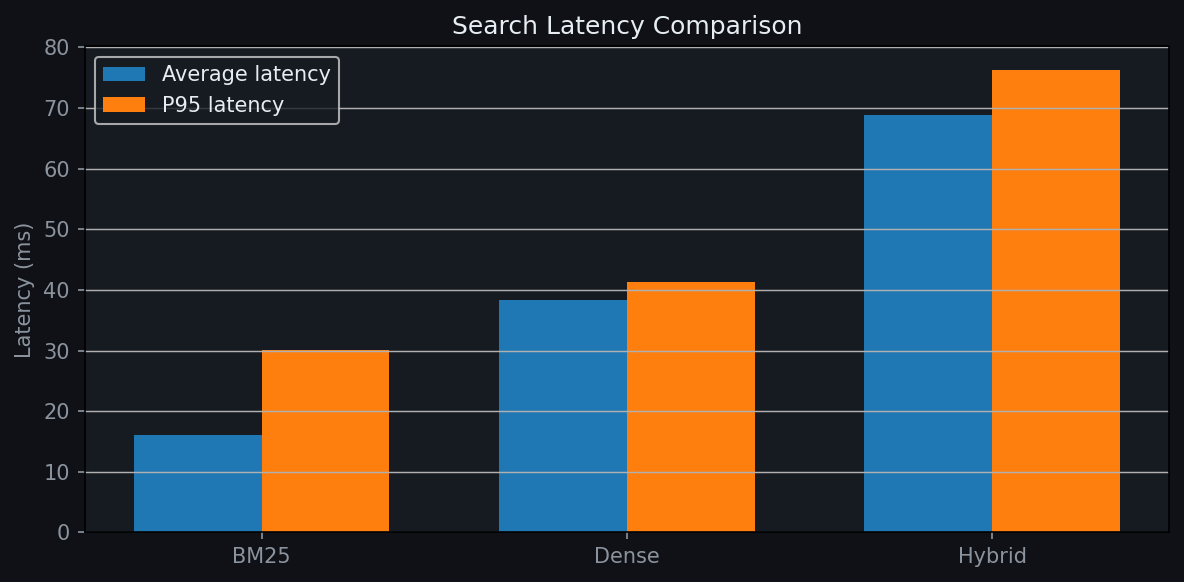

In [59]:
# ── Display Member 2's cached plots for context ──
print("=" * 55)
print("SECTION 1 — SEMANTIC RETRIEVAL OUTPUTS (Member 2)")
print("=" * 55)

fig_pca, ax = plt.subplots(figsize=(10, 1))
ax.axis("off")
ax.set_title("Plot 1 — Chunk Embedding Space (PCA)", 
             fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()
display(Image(str(CACHE_02 / "pca_embeddings.png")))

fig_lat, ax = plt.subplots(figsize=(10, 1))
ax.axis("off")
ax.set_title("Plot 2 — Search Latency Comparison (Member 2)", 
             fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()
display(Image(str(CACHE_02 / "latency_comparison.png")))

SECTION 2 — EVALUATION METRICS (Member 4)

Plot 3 — BM25 vs Dense vs Hybrid: Quality + Latency


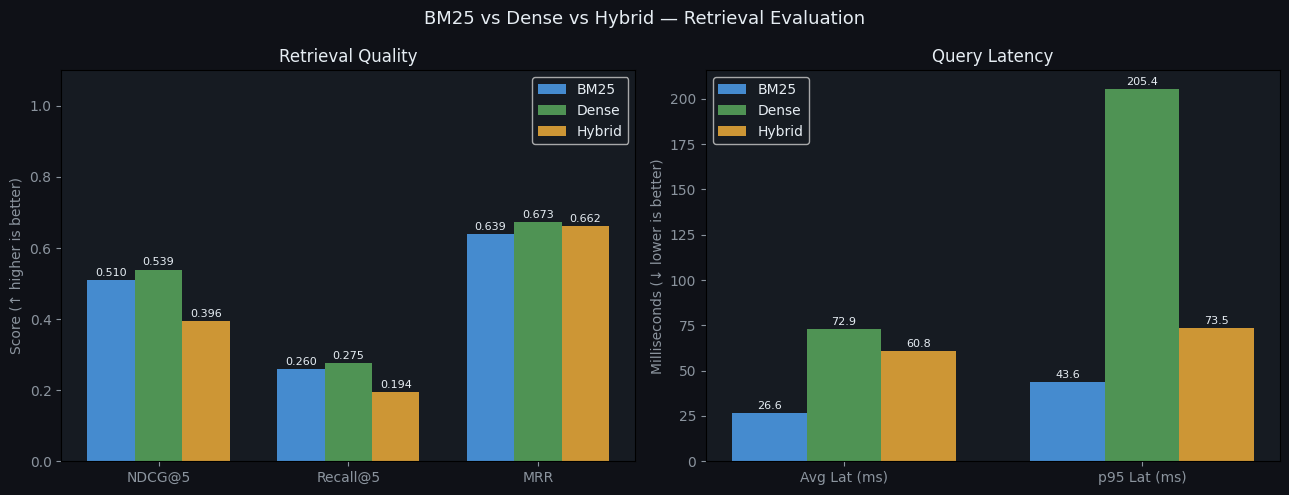

In [60]:
# ── Summary table ──
summary_rows = []
for method_name, per_query in results_store.items():
    lats = [r["latency_ms"] for r in per_query]
    summary_rows.append({
        "Method":       method_name,
        "NDCG@5":       round(np.mean([r["ndcg@5"]   for r in per_query]), 4),
        "Recall@5":     round(np.mean([r["recall@5"] for r in per_query]), 4),
        "MRR":          round(np.mean([r["mrr"]      for r in per_query]), 4),
        "Avg Lat (ms)": round(np.mean(lats), 2),
        "p95 Lat (ms)": round(float(np.percentile(lats, 95)), 2),
    })

summary_df = pd.DataFrame(summary_rows)

print("=" * 55)
print("SECTION 2 — EVALUATION METRICS (Member 4)")
print("=" * 55)
print("\nPlot 3 — BM25 vs Dense vs Hybrid: Quality + Latency")

# ── Bar chart ──
colors       = {"BM25": "#4C9BE8", "Dense": "#58A55C", "Hybrid": "#E8A838"}
methods_list = ["BM25", "Dense", "Hybrid"]
bar_w        = 0.25

fig, (ax_q, ax_l) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("BM25 vs Dense vs Hybrid — Retrieval Evaluation", fontsize=13)

# Quality panel
q_metrics = ["NDCG@5", "Recall@5", "MRR"]
xs = np.arange(len(q_metrics))
for i, method in enumerate(methods_list):
    row  = summary_df[summary_df["Method"] == method].iloc[0]
    vals = [row["NDCG@5"], row["Recall@5"], row["MRR"]]
    bars = ax_q.bar(xs + i * bar_w, vals, bar_w,
                    label=method, color=colors[method], alpha=0.88)
    for bar, val in zip(bars, vals):
        ax_q.annotate(f"{val:.3f}",
                      xy=(bar.get_x() + bar_w / 2, val),
                      xytext=(0, 3), textcoords="offset points",
                      ha="center", fontsize=8)

ax_q.set_xticks(xs + bar_w)
ax_q.set_xticklabels(q_metrics)
ax_q.set_ylabel("Score (↑ higher is better)")
ax_q.set_title("Retrieval Quality")
ax_q.legend()
ax_q.set_ylim(0, 1.1)

# Latency panel
l_metrics = ["Avg Lat (ms)", "p95 Lat (ms)"]
xs2 = np.arange(len(l_metrics))
for i, method in enumerate(methods_list):
    row  = summary_df[summary_df["Method"] == method].iloc[0]
    vals = [row["Avg Lat (ms)"], row["p95 Lat (ms)"]]
    bars = ax_l.bar(xs2 + i * bar_w, vals, bar_w,
                    label=method, color=colors[method], alpha=0.88)
    for bar, val in zip(bars, vals):
        ax_l.annotate(f"{val:.1f}",
                      xy=(bar.get_x() + bar_w / 2, val),
                      xytext=(0, 3), textcoords="offset points",
                      ha="center", fontsize=8)

ax_l.set_xticks(xs2 + bar_w)
ax_l.set_xticklabels(l_metrics)
ax_l.set_ylabel("Milliseconds (↓ lower is better)")
ax_l.set_title("Query Latency")
ax_l.legend()

plt.tight_layout()
plt.savefig(str(CACHE_04 / "eval_bar_chart.png"), dpi=150, bbox_inches="tight")
plt.show()

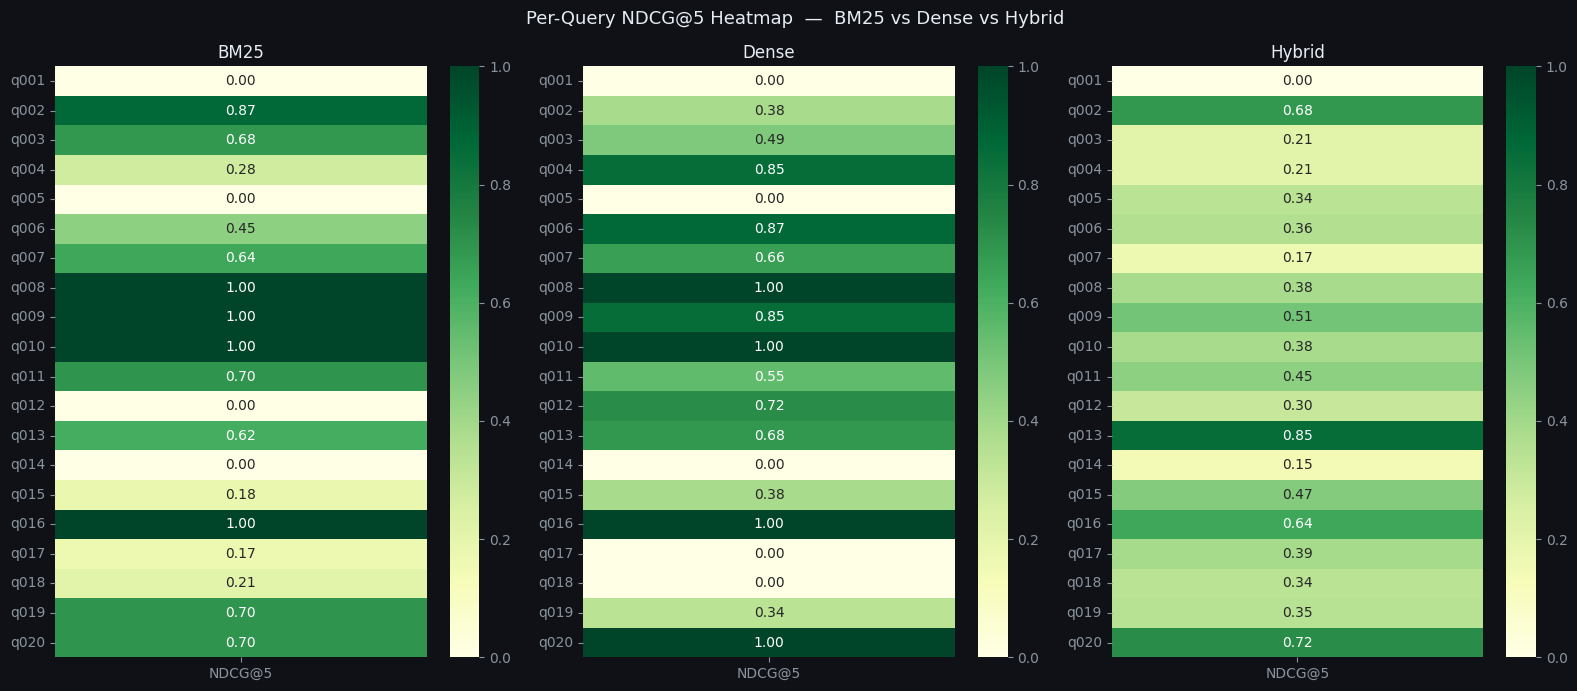

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.suptitle("Per-Query NDCG@5 Heatmap  —  BM25 vs Dense vs Hybrid", fontsize=13)

for ax, method in zip(axes, methods_list):
    per_query = results_store[method]
    qids  = [r["query_id"] for r in per_query]
    ndcgs = [[r["ndcg@5"]] for r in per_query]

    sns.heatmap(ndcgs, ax=ax, vmin=0, vmax=1,
                cmap="YlGn", annot=True, fmt=".2f",
                yticklabels=qids, xticklabels=["NDCG@5"])
    ax.set_title(method)

plt.tight_layout()
plt.savefig(str(CACHE_04 / "eval_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

In [62]:
import pandas as pd
import numpy as np
from IPython.display import display

# Check that evaluation results exist
if "results_store" not in globals():
    raise NameError("results_store is missing. Run the evaluation loop cell first.")

summary_rows = []

for method_name, rows in results_store.items():
    df = pd.DataFrame(rows)

    summary_rows.append({
        "Method": method_name,
        "NDCG@5": round(df["ndcg@5"].mean(), 4),
        "Recall@5": round(df["recall@5"].mean(), 4),
        "MRR": round(df["mrr"].mean(), 4),
        "Avg Latency (ms)": round(df["latency_ms"].mean(), 2),
        "p95 Latency (ms)": round(np.percentile(df["latency_ms"], 95), 2)
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

# Find best methods
best_ndcg = summary_df.loc[summary_df["NDCG@5"].idxmax(), "Method"]
best_recall = summary_df.loc[summary_df["Recall@5"].idxmax(), "Method"]
fastest = summary_df.loc[summary_df["Avg Latency (ms)"].idxmin(), "Method"]

print("Summary:")
print(f"- Best NDCG@5: {best_ndcg}")
print(f"- Best Recall@5: {best_recall}")
print(f"- Fastest method: {fastest}")

if "Hybrid" in summary_df["Method"].values:
    print("- Hybrid usually gives a balance between semantic and lexical matching.")

if "BM25" in summary_df["Method"].values:
    print("- BM25 is usually fastest because it uses keyword matching only.")

if "Dense" in summary_df["Method"].values:
    print("- Dense search captures semantic meaning but depends on embedding quality.")

,Method,NDCG@5,Recall@5,MRR,Avg Latency (ms),p95 Latency (ms)
0,BM25,0.5097,0.2598,0.6394,26.60,43.59
1,Dense,0.5395,0.2752,0.6731,72.92,205.41
2,Hybrid,0.3956,0.1936,0.6625,60.77,73.50


Summary:
- Best NDCG@5: Dense
- Best Recall@5: Dense
- Fastest method: BM25
- Hybrid usually gives a balance between semantic and lexical matching.
- BM25 is usually fastest because it uses keyword matching only.
- Dense search captures semantic meaning but depends on embedding quality.



Plot — Recall@k and NDCG@k curves (k = 1 to 10)


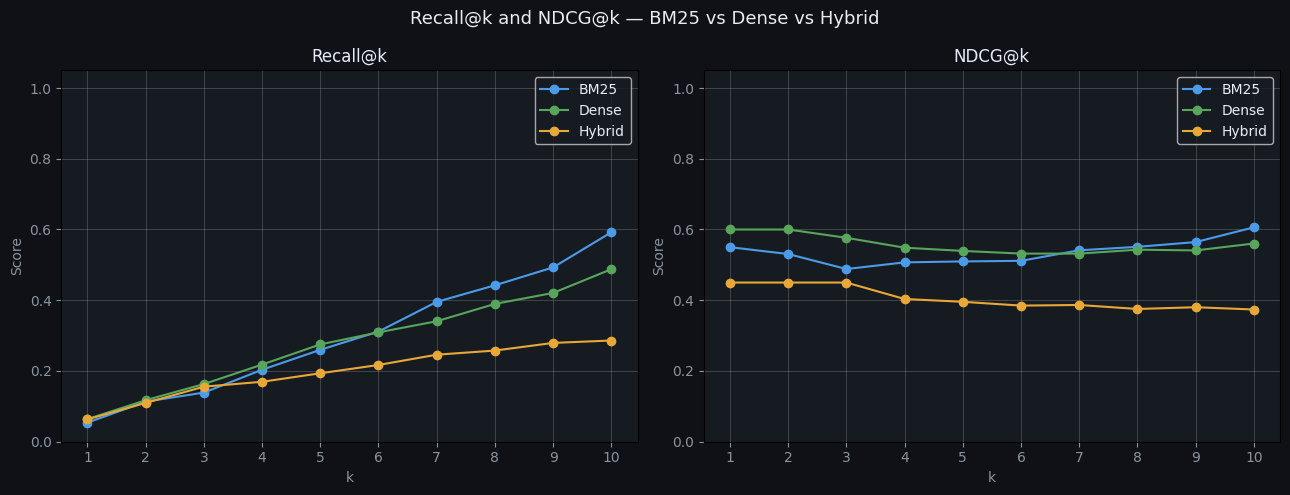

In [63]:
print("\nPlot — Recall@k and NDCG@k curves (k = 1 to 10)")

K_VALUES = list(range(1, 11))
colors   = {"BM25": "#4C9BE8", "Dense": "#58A55C", "Hybrid": "#E8A838"}

fig, (ax_r, ax_n) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Recall@k and NDCG@k — BM25 vs Dense vs Hybrid", fontsize=13)

for method, per_query in results_store.items():
    df = pd.DataFrame(per_query)
    recall_curve = [df[f"recall@{k}"].mean() for k in K_VALUES]
    ndcg_curve   = [df[f"ndcg@{k}"].mean()   for k in K_VALUES]

    ax_r.plot(K_VALUES, recall_curve, marker="o", label=method, color=colors[method])
    ax_n.plot(K_VALUES, ndcg_curve,   marker="o", label=method, color=colors[method])

for ax, title in [(ax_r, "Recall@k"), (ax_n, "NDCG@k")]:
    ax.set_xlabel("k")
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend()
    ax.set_xticks(K_VALUES)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linewidth=0.5, alpha=0.4)

plt.tight_layout()
fig.savefig(str(CACHE_04 / "eval_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


Plot — Method Profile Radar Chart


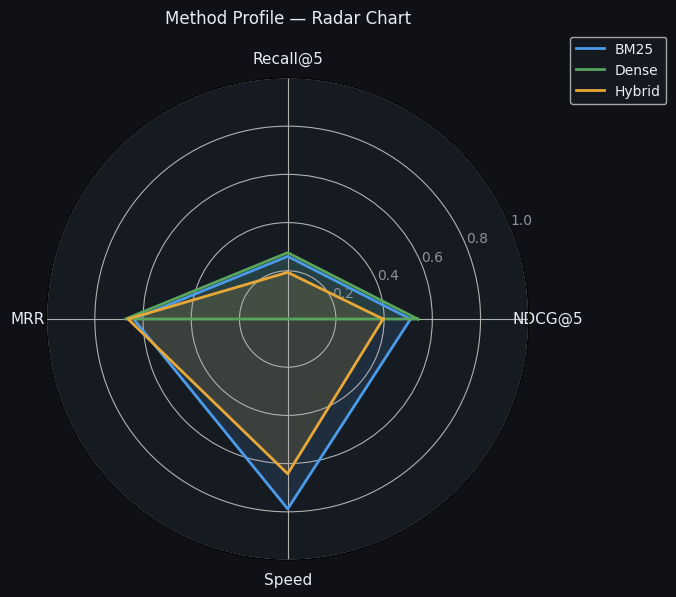

In [65]:
print("\nPlot — Method Profile Radar Chart")

categories = ["NDCG@5", "Recall@5", "MRR", "Speed"]
N          = len(categories)
angles     = [n / float(N) * 2 * math.pi for n in range(N)]
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor('#161b22')
fig.patch.set_facecolor('#0f1117')

max_lat = summary_df["p95 Latency (ms)"].max()

for method in methods_list:
    row         = summary_df[summary_df["Method"] == method].iloc[0]
    speed_score = 1 - (row["p95 Latency (ms)"] / max_lat)
    values      = [row["NDCG@5"], row["Recall@5"], row["MRR"], speed_score]
    values     += values[:1]

    ax.plot(angles, values, color=colors[method], linewidth=2, label=method)
    ax.fill(angles, values, color=colors[method], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color='#e6edf3', size=11)
ax.set_ylim(0, 1)
ax.set_title("Method Profile — Radar Chart", color='#e6edf3', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
fig.savefig(str(CACHE_04 / "eval_radar.png"), dpi=150, bbox_inches="tight")
plt.show()